In [1]:
import os, sys
sys.path.append(os.path.join(os.environ.get('IDEFIX_DIR','../../../../'), 'pytools'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import dump_io as io

from astropy import constants as const, units as u

%matplotlib inline


In [2]:
dirc = 'out/'

def load(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer][0]
def load3D(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer]

In [3]:
dmp = io.readDump(f'{dirc}/dump.0000.dmp')
r, th, phi = dmp.x1, dmp.x2, dmp.x3


uL = 1e8 *u.cm.cgs
uM = 1e24*u.g.cgs
uv = 1e5*u.cm.cgs/u.s.cgs
uT = ((u.g.cgs/u.mol.cgs) * uv**2 / (const.k_B.cgs * const.N_A.cgs)).decompose()
ud = uM/uL**3

mu = 2.353


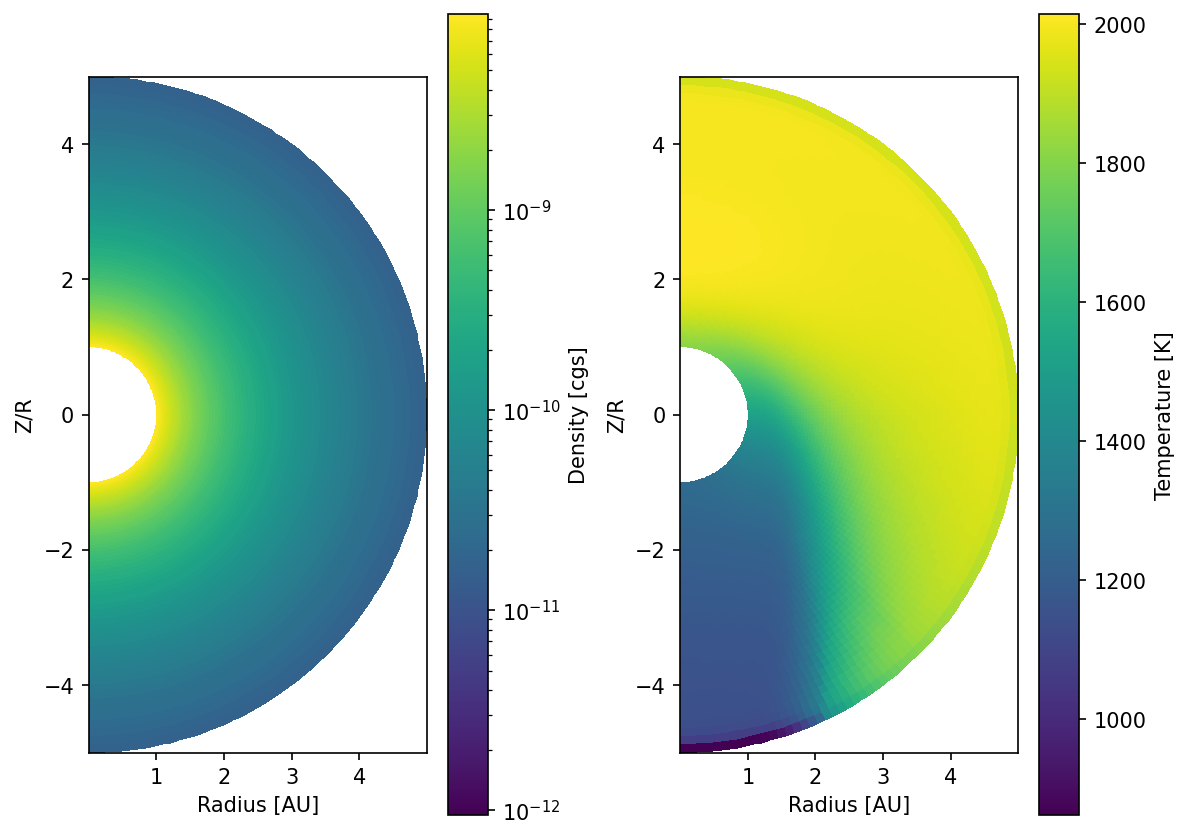

In [4]:
fig, ax = plt.subplots(ncols=2, dpi=150, figsize=(8,6))
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

snap = 10

rho = load(i=snap, var='Vc-RHO')
P = load(i=snap, var='Vc-PRS')
Er = load(i=snap, var='ERAD')

T = mu * (P/rho)

z = r*np.cos(th[:,None])
x = r*np.sin(th[:,None])

im = ax[0].pcolormesh(x, z, rho * ud.to_value('g/cm**3'), norm=LogNorm(vmin=1e-4*rho.max() *ud.to_value('g/cm**3')))
ax[0].set_xlabel('Radius [AU]')
ax[0].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[0], label='Density [cgs]')

im = ax[1].pcolormesh(x, z, T * uT.to_value('K'))
ax[1].set_xlabel('Radius [AU]')
ax[1].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[1], label='Temperature [K]')

fig.tight_layout()
